In [2]:
import numpy as np
from shapely.geometry import shape, mapping, Polygon, MultiPolygon

import requests

In [11]:
def simplify_geojson_polygon(geom, tol: float = 0.003):
    if isinstance(geom, MultiPolygon):
        geom = max(geom.geoms, key=lambda g: g.area)

    geom = Polygon(geom.exterior.coords)  # remove holes

    # simplify: increase tolerance for coarser shape
    # 0.002 degrees is roughly a few hundred feet; 0.005 is much coarser
    return geom.simplify(tol, preserve_topology=False)

{'type': 'Polygon', 'coordinates': (((-82.9105544305786, 42.4171900613737), (-82.9214901309786, 42.3954601421411), (-82.9467971754137, 42.3869905360599), (-82.9239682468776, 42.3521239320005), (-82.9597674925587, 42.3397696595272), (-83.018944892249, 42.3306167502245), (-83.0635576520147, 42.316858205609), (-83.0799405710076, 42.3071723138093), (-83.0998979296352, 42.286698833415), (-83.1181284019949, 42.2897279934914), (-83.1187726296992, 42.2791343949034), (-83.1374512868255, 42.2827918763971), (-83.1609726637321, 42.2549612971133), (-83.1698284246862, 42.2645773329098), (-83.1581612800492, 42.2788447744732), (-83.1669952478746, 42.2895722094552), (-83.1404493556957, 42.2977492956964), (-83.1407013106751, 42.3110091896487), (-83.1564717178831, 42.3272404638746), (-83.1569019614968, 42.3369613293605), (-83.1499416529787, 42.3398377874351), (-83.1476571285151, 42.3519163462992), (-83.1965297101378, 42.3508911560872), (-83.1960557491125, 42.3364353270122), (-83.2153359531873, 42.3361363

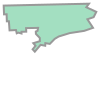

In [12]:
# download boundary for Detroit
URL = "https://data.detroitmi.gov/api/download/v1/items/86b221bb68ca4364afe81d156e54f95c/geojson?layers=0"

data = requests.get(URL, timeout=60).json()
geom = shape(data["features"][0]["geometry"])
geom = simplify_geojson_polygon(geom)

print(mapping(geom))
geom

{'type': 'Polygon', 'coordinates': (((-83.55181519986245, 42.434370939992355), (-83.94464363676845, 42.424148677599426), (-84.13112978994177, 42.424566582507914), (-84.13195838168929, 42.07157597993666), (-84.00814731756785, 42.07359606379444), (-84.00833183767111, 42.078003354997875), (-83.53938897145694, 42.08559552351619), (-83.55181519986245, 42.434370939992355)),)}


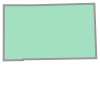

In [14]:
URL = "https://maps-semcog.opendata.arcgis.com/api/download/v1/items/aa922747f3964fd0bba38d78de3ebc63/geojson?layers=8"

data = requests.get(URL, timeout=60).json()

# find Washtenaw County feature
feat = None
for f in data["features"]:
    props = f.get("properties", {})
    vals = {str(v).strip().lower() for v in props.values() if v is not None}
    if "washtenaw" in vals or "washtenaw county" in vals:
        feat = f
        break

if feat is None:
    raise RuntimeError("Could not find Washtenaw County in source GeoJSON")

geom = shape(feat["geometry"])
geom = simplify_geojson_polygon(geom)

print(mapping(geom))
geom

In [5]:
# convert GeoJSON polygon to a list of coordinates

INTERCHANGES_RAW = [
    {"type": "Polygon", "coordinates": [[[-83.7653053184995, 42.24695964710352], [-83.7653053184995, 42.24509281118205],
                                         [-83.76275861187068, 42.24509281118205],
                                         [-83.76275861187068, 42.24695964710352],
                                         [-83.7653053184995, 42.24695964710352]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.74015017566227, 42.23774097697641], [-83.74015017566227, 42.23605048903499],
         [-83.73792020364262, 42.23605048903499], [-83.73792020364262, 42.23774097697641],
         [-83.74015017566227, 42.23774097697641]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68660719232598, 42.22658232594573], [-83.68660719232598, 42.224802767846434],
         [-83.68424050321555, 42.224802767846434], [-83.68424050321555, 42.22658232594573],
         [-83.68660719232598, 42.22658232594573]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68519752285086, 42.25546774214873], [-83.68519752285086, 42.2537539885268],
         [-83.68270093245769, 42.2537539885268], [-83.68270093245769, 42.25546774214873],
         [-83.68519752285086, 42.25546774214873]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68857539500242, 42.307200975706685], [-83.68857539500242, 42.3054901375886],
         [-83.68609755756299, 42.3054901375886], [-83.68609755756299, 42.307200975706685],
         [-83.68857539500242, 42.307200975706685]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.74855035499152, 42.301261500288085], [-83.74855035499152, 42.29988261363462],
         [-83.74655327973984, 42.29988261363462], [-83.74655327973984, 42.301261500288085],
         [-83.74855035499152, 42.301261500288085]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78825960166517, 42.299086240275884], [-83.78825960166517, 42.29751961679856],
         [-83.78595539072994, 42.29751961679856], [-83.78595539072994, 42.299086240275884],
         [-83.78825960166517, 42.299086240275884]]]}
]

OVERPASSES_RAW = [
    {"type": "Polygon", "coordinates": [
        [[-83.72065443320648, 42.237651471473384], [-83.72065443320648, 42.23686885402677],
         [-83.71965779814654, 42.23686885402677], [-83.71965779814654, 42.237651471473384],
         [-83.72065443320648, 42.237651471473384]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.70013643938798, 42.23263938226738], [-83.70013643938798, 42.23191794854806],
         [-83.69935695982517, 42.23191794854806], [-83.69935695982517, 42.23263938226738],
         [-83.70013643938798, 42.23263938226738]]]},
    {"type": "Polygon", "coordinates": [[[-83.6860436272189, 42.2309475936862], [-83.6860436272189, 42.23024168958983],
                                         [-83.68496888780194, 42.23024168958983],
                                         [-83.68496888780194, 42.2309475936862],
                                         [-83.6860436272189, 42.2309475936862]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68403816600447, 42.24578228019548], [-83.68403816600447, 42.24515231376033],
         [-83.6831281692095, 42.24515231376033], [-83.6831281692095, 42.24578228019548],
         [-83.68403816600447, 42.24578228019548]]]},
    {"type": "Polygon", "coordinates": [[[-83.6831712809513, 42.29502296896619], [-83.6831712809513, 42.29410786241498],
                                         [-83.68209171348968, 42.29410786241498],
                                         [-83.68209171348968, 42.29502296896619],
                                         [-83.6831712809513, 42.29502296896619]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.70828346106319, 42.32429627193206], [-83.70828346106319, 42.323685932804864],
         [-83.70744465315146, 42.323685932804864], [-83.70744465315146, 42.32429627193206],
         [-83.70828346106319, 42.32429627193206]]]},
    {"type": "Polygon", "coordinates": [[[-83.73583255375239, 42.32023765134], [-83.73583255375239, 42.31941550032116],
                                         [-83.73486407734694, 42.31941550032116], [-83.73486407734694, 42.32023765134],
                                         [-83.73583255375239, 42.32023765134]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.76626238447042, 42.2993415694097], [-83.76626238447042, 42.29872522220684],
         [-83.76544945524273, 42.29872522220684], [-83.76544945524273, 42.2993415694097],
         [-83.76626238447042, 42.2993415694097]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.80025005101768, 42.29079492822921], [-83.80025005101768, 42.289853415187515],
         [-83.7988783537706, 42.289853415187515], [-83.7988783537706, 42.29079492822921],
         [-83.80025005101768, 42.29079492822921]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78337787301311, 42.28208581687849], [-83.78485546123454, 42.28208581687849],
         [-83.78485546123454, 42.28107150027606], [-83.78337787301311, 42.28107150027606],
         [-83.78337787301311, 42.28208581687849]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78480983499519, 42.27312583402841], [-83.78480983499519, 42.27226297526143],
         [-83.78384466454183, 42.27226297526143], [-83.78384466454183, 42.27312583402841],
         [-83.78480983499519, 42.27312583402841]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.77661422170391, 42.256574286289904], [-83.77800450587073, 42.256574286289904],
         [-83.77800450587073, 42.255639763725604], [-83.77661422170391, 42.255639763725604],
         [-83.77661422170391, 42.256574286289904]]]},
]

CHARGERS5 = [
    # centre
    {"coordinates": [[[-83.7378897407689, 42.27752162482751], [-83.73482383717868, 42.27752162482751],
                      [-83.73482383717868, 42.275529373109975], [-83.7378897407689, 42.275529373109975],
                      [-83.7378897407689, 42.27752162482751]]]},

    # north
    {"coordinates": [[[-83.71124736424815, 42.306030926087566], [-83.71124736424815, 42.30483429465836],
                      [-83.7092241682606, 42.30483429465836], [-83.7092241682606, 42.306030926087566],
                      [-83.71124736424815, 42.306030926087566]]]},

    # south
    {"coordinates": [[[-83.75139742143158, 42.24628816468756], [-83.75139742143158, 42.24464723904189],
                      [-83.74957850668383, 42.24464723904189], [-83.74957850668383, 42.24628816468756],
                      [-83.75139742143158, 42.24628816468756]]]},

    # east
    {"coordinates": [[[-83.69521399263594, 42.25210742322293], [-83.69521399263594, 42.250498193073106],
                      [-83.6928336426927, 42.250498193073106], [-83.6928336426927, 42.25210742322293],
                      [-83.69521399263594, 42.25210742322293]]]},

    # west
    {"coordinates": [[[-83.77699954277293, 42.27353470926183], [-83.77699954277293, 42.271900498863815],
                      [-83.7749141154144, 42.271900498863815], [-83.7749141154144, 42.27353470926183],
                      [-83.77699954277293, 42.27353470926183]]]}
]

CHARGERS1 = [
    {"type": "Polygon", "coordinates": [
        [[-83.73831640480778, 42.27855981922442], [-83.73831640480778, 42.276014512783334],
         [-83.73457776047084, 42.276014512783334], [-83.73457776047084, 42.27855981922442],
         [-83.73831640480778, 42.27855981922442]]]}
]

CHARGERS2 = [
    {"type": "Polygon", "coordinates": [
        [[-83.74491770063037, 42.2632820193812], [-83.74491770063037, 42.26059114181942],
         [-83.74094736902258, 42.26059114181942], [-83.74094736902258, 42.2632820193812],
         [-83.74491770063037, 42.2632820193812]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.71727466241134, 42.29012175342128], [-83.71727466241134, 42.28719877950635],
         [-83.71350616145824, 42.28719877950635], [-83.71350616145824, 42.29012175342128],
         [-83.71727466241134, 42.29012175342128]]]}
]

radians = False
for interchange in CHARGERS1:
    lons, lats = zip(*interchange["coordinates"][0])
    mean_lon = np.mean(lons)
    mean_lat = np.mean(lats)

    if radians:
        mean_lat = np.deg2rad(mean_lat)
        mean_lon = np.deg2rad(mean_lon)

    print(f"[{mean_lat}, {mean_lon}],")

[42.27754169664799, -83.736820947073],
